In [2]:
import sys
sys.path.insert(0, "../..")

from src.models        import DeepONet, build_deeponet
from src.data          import ODEIterableDataset, LatinHypercubeSampler
from src.physics       import harm_osc, ODEsolver

import numpy as np
import matplotlib.pyplot as plt 
import torch
from torch.utils.data import DataLoader

device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Initialize Harmonic Oscillator Object 
k = 2.0
c = 0.1
system = harm_osc([k, c])
solver = ODEsolver(system).solve

# Initialize Sampler Object 
sampler = LatinHypercubeSampler(

    dimensions = 2,
    lows       = [-1.0, -1.0],
    highs      = [1.0, 1.0]
    
)

In [4]:
dataset_size = 1001
batch_size   = 1
num_workers  = 2
t_final      = 10
t_span       = (0, t_final)

osc_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 full_solution = False)

osc_loader  = DataLoader(dataset     = osc_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)


In [5]:
# Set Up DeepONet configuration 

DEEPONET_CONFIG = {
    
    "hidden_size" : 128,
    "depth"       : 6,
    "latent_size" : 50,
    "input_size_b": 2,
    "input_size_t": 1,
    "output_size" : 2,
    "activation"  : "tanh",

}

# 1. Initialize DeepONet network 

deeponet = build_deeponet(DEEPONET_CONFIG)

# 2. Load the saved weights into the model

state_dict = torch.load("../../weights/best_2d_osc.pth", map_location=device)
deeponet.load_state_dict(state_dict)
deeponet = deeponet.to(device)

# 3. Set to eval mode
deeponet.eval()
_ = 0

In [8]:
from src.benchmark import trajectory 

t, sol, pred = trajectory(deeponet, osc_loader, device)

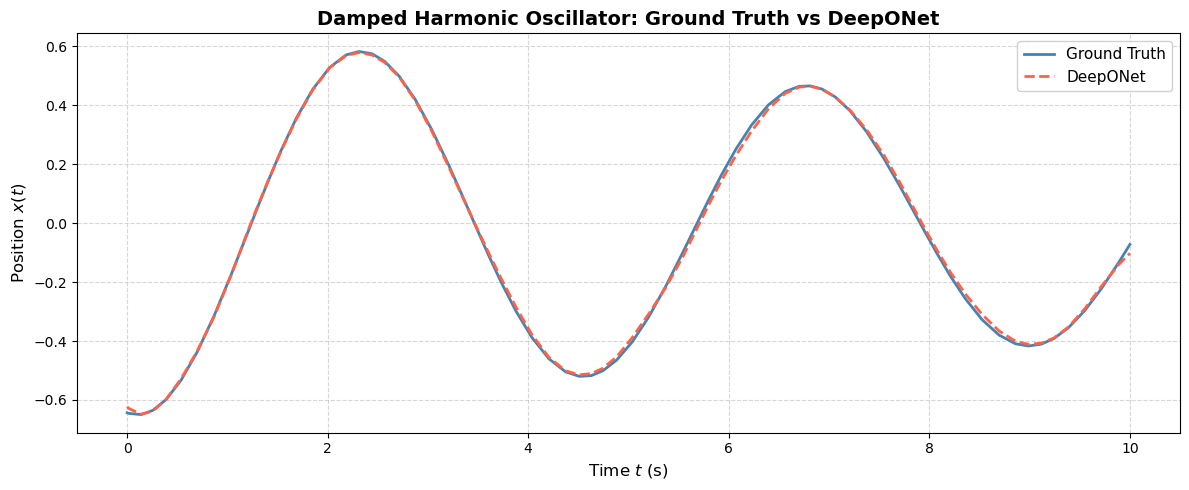

In [26]:
# Plotting 

plt.figure(figsize=(12, 5))
plt.plot(t, sol[0], color="steelblue", lw=2, label="Ground Truth")
plt.plot(t, pred[:, 0], color="tomato",    lw=2, label="DeepONet", linestyle="--")
plt.title("Damped Harmonic Oscillator: Ground Truth vs DeepONet", fontsize=14, fontweight="bold")
plt.ylabel("Position $x(t)$", fontsize=12)
plt.xlabel("Time $t$ (s)", fontsize=12)
plt.legend(fontsize=11, framealpha=0.9)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
from src.benchmark import timing_data

num_boxes   = 10
num_samples = 1000

nn_timing, solver_timing = timing_data(model       = deeponet, 
                                       ODEsolver   = solver, 
                                       sampler     = sampler,
                                       t_final     = t_final, 
                                       num_samples = num_samples,
                                       num_boxes   = num_boxes, 
                                       device      = device)


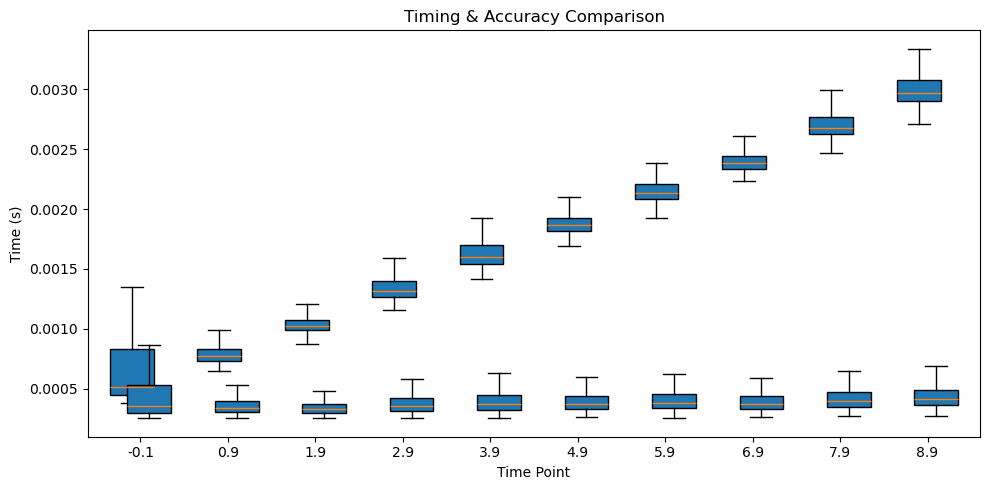

In [38]:
# --- Timing boxplots ---
plt.figure(figsize=(10, 5))

plt.boxplot(solver_timing, 
            positions    = np.arange(num_boxes) - 0.1,
            widths       = 0.5, 
            patch_artist = True,
            showfliers   = False)
                  
plt.boxplot(nn_timing, 
            positions    = np.arange(num_boxes) + 0.1,
            widths       = 0.5, 
            patch_artist = True,
            showfliers   = False)

plt.xticks(np.arange(num_boxes))
plt.xlabel("Time Point")
plt.ylabel("Time (s)")

plt.title("Timing & Accuracy Comparison")
plt.tight_layout()
plt.show()

In [45]:
from src.benchmark import semigroup_data

loss_fn = torch.nn.MSELoss()

loss_direct, loss_2step, loss_3step = semigroup_data(model       = deeponet, 
                                                     ODEsolver   = solver, 
                                                     sampler     = sampler,
                                                     loss_fn     = loss_fn,
                                                     t_final     = t_final, 
                                                     num_samples = num_samples, 
                                                     num_boxes   = num_boxes, 
                                                     out_mask    = [0, 1],
                                                     device      = device)

/home/enricp/miniconda3/envs/physics/lib/python3.12/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([2])) that is different to the input size (torch.Size([1, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


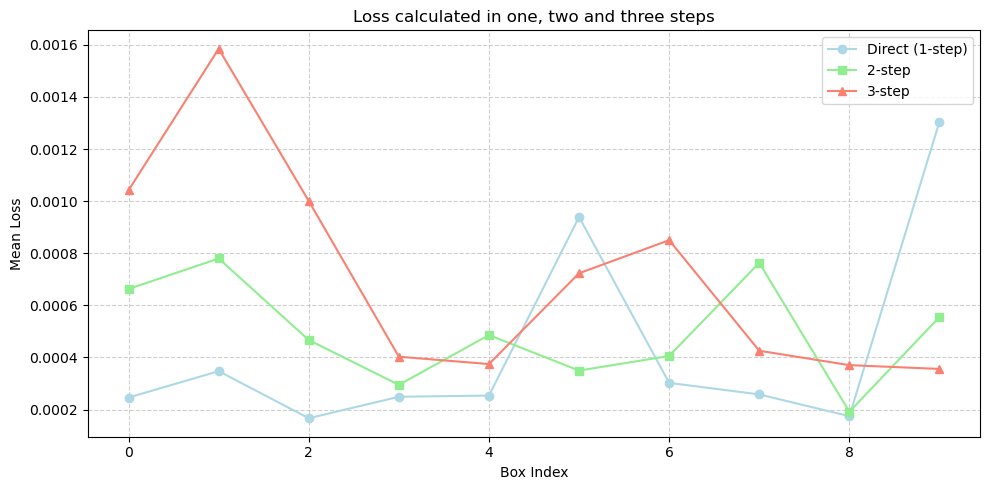

In [58]:
plt.figure(figsize=(10, 5))

x = np.arange(num_boxes)

plt.plot(x, loss_direct_means_1, marker='o', label='Direct (1-step)', color='lightblue')
plt.plot(x, loss_direct_means_2, marker='s', label='2-step',          color='lightgreen')
plt.plot(x, loss_direct_means_3, marker='^', label='3-step',          color='salmon')

plt.xlabel("Box Index")
plt.ylabel("Mean Loss")
plt.title("Loss calculated in one, two and three steps")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

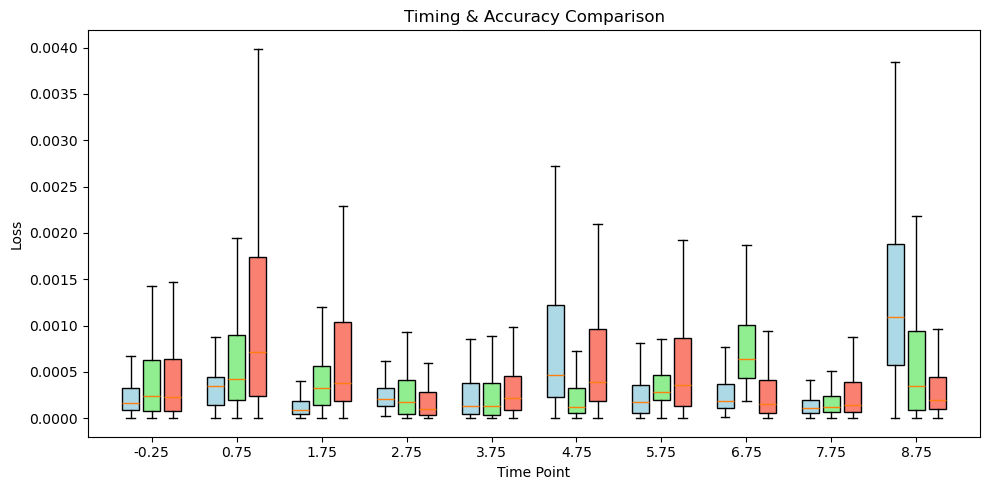

In [46]:
plt.figure(figsize=(10, 5))

bp1 = plt.boxplot(loss_direct,
                  positions    = np.arange(num_boxes) - 0.25,
                  widths       = 0.2,
                  patch_artist = True,
                  showfliers   = False)

bp2 = plt.boxplot(loss_2step,
                  positions    = np.arange(num_boxes),
                  widths       = 0.2,
                  patch_artist = True,
                  showfliers   = False)

bp3 = plt.boxplot(loss_3step,
                  positions    = np.arange(num_boxes) + 0.25,
                  widths       = 0.2,
                  patch_artist = True,
                  showfliers   = False)

# Set colors
for box in bp1['boxes']:
    box.set_facecolor('lightblue')

for box in bp2['boxes']:
    box.set_facecolor('lightgreen')

for box in bp3['boxes']:
    box.set_facecolor('salmon')

plt.xticks(np.arange(num_boxes))
plt.xlabel("Time Point")
plt.ylabel("Loss")
plt.title("Timing & Accuracy Comparison")

plt.tight_layout()
plt.show()